In [ ]:
# dependencies

from Bio import AlignIO
from Bio import SeqIO
import re
import pandas as pd
import seaborn as sns
from matplotlib.colors import LogNorm


In [3]:
# results in FASTA form into dataframe

def pfam_results(results_input):
    data = {'accession': [], 'taxon': [], 'seq identifier': [], 'I Helix': []}
    with open(results_input) as fp:
        for record in SeqIO.parse(fp, "fasta"):
            seqident = re.findall(r"\|(?P<sequence_id>\w+)\|", record.id)
            accession = record.description
            taxon = re.findall(r"OX=(\d+)", record.description)
            sequence = str(record.seq)

            # attaching to dictionary
            data['seq identifier'].append(", ".join(seqident))
            data['accession'].append(accession)
            data['taxon'].append(", ".join(taxon))
            data['I Helix'].append(sequence)

    df = pd.DataFrame.from_dict(data)
    return df

In [4]:
# Converting HMM search output for pfam data to FASTA file
input = '/home/alecia/chapter3-repo/output/hmm_search_2/pfam/3/ihelixhits_e_0p001_z__T_.aln'
outfile_fasta = '/home/alecia/chapter3-repo/output/hmm_search_2/pfam/3/ihelixhits_e_0p001_z__T_.fasta'

with open(input) as infile:
    alignment = AlignIO.read(infile, 'stockholm')

SeqIO.write(alignment, outfile_fasta, 'fasta')

278757

In [5]:
pfam_r1 = pfam_results('/home/alecia/chapter3-repo/output/hmm_search_1/pfam/3/ihelixhits_e_0p001_z__T_.fasta')
pfam_r2 = pfam_results('/home/alecia/chapter3-repo/output/hmm_search_2/pfam/3/ihelixhits_e_0p001_z__T_.fasta')

In [6]:
pfam_r1

,accession,taxon,seq identifier,I Helix
0,tr|A0A498MRP4|A0A498MRP4_LABRO/720-751 [subseq...,84645,A0A498MRP4,-DGLVIACL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY
1,tr|A0A498MRP4|A0A498MRP4_LABRO/1166-1197 [subs...,84645,A0A498MRP4,-EGLVISCL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY
2,tr|A0A498MRP4|A0A498MRP4_LABRO/1618-1649 [subs...,84645,A0A498MRP4,-DGLVIICL-DV-I-EA--G---TET--T--T-T--TLR-WGLLFMIKY
3,tr|A0A498MRP4|A0A498MRP4_LABRO/2174-2205 [subs...,84645,A0A498MRP4,-DGLVISCL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY
4,tr|A0A498MRP4|A0A498MRP4_LABRO/2626-2657 [subs...,84645,A0A498MRP4,-DGLVISCL-DV-I-EA--G---SET--T--A-T--TLR-WGLLFMIKY
...,...,...,...,...
162079,tr|A0A2S3GQM6|A0A2S3GQM6_9POAL/311-340 [subseq...,206008,A0A2S3GQM6,---LRDFCI-SF-V-LA--G---RDT--S--S-V--ALA-WFFWLLASH
162080,tr|A0A8X7P7K3|A0A8X7P7K3_BRACI/295-322 [subseq...,52824,A0A8X7P7K3,-----RECK-LF-Y-FA--G---QET--T--S-V--LLV-WTMILLSHH
162081,tr|A0A7S8A7J9|A0A7S8A7J9_9BRAD/226-256 [subseq...,1325114,A0A7S8A7J9,-DEMVSMVF-LL-L-AA--G---SET--T--T-H--LIS-GSAYELLR-
162082,tr|A0A395IRT2|A0A395IRT2_9HELO/207-235 [subseq...,38457,A0A395IRT2,---ILANMI-TF-L-IA--G---HET--I--S-G--ILS-FVFLNLMK-


In [7]:
pfam_r2

,accession,taxon,seq identifier,I Helix
0,tr|A0A182XW67|A0A182XW67_ANOST/287-321 [subseq...,30069,A0A182XW67,LDMTQV--AGQCY-S-F-F-I--A----G------FE--T-SAS--...
1,tr|A0A182XW67|A0A182XW67_ANOST/819-853 [subseq...,30069,A0A182XW67,MTLNEL--AAQVF-I-F-F-L--A----G------FE--T-SST--...
2,tr|A0A182XW67|A0A182XW67_ANOST/1316-1351 [subs...,30069,A0A182XW67,LTMNEL--AAQVF-I-F-F-V--A----G------FE--T-SST--...
3,tr|A0A182XW67|A0A182XW67_ANOST/1825-1860 [subs...,30069,A0A182XW67,LTLNEL--AAQVF-V-F-F-L--A----G------FE--T-SST--...
4,tr|A0A182XW67|A0A182XW67_ANOST/2334-2369 [subs...,30069,A0A182XW67,LTHNEL--AAQVL-I-F-F-L--A----G------FE--T-SST--...
...,...,...,...,...
278752,tr|A0A1Y2UC39|A0A1Y2UC39_9PEZI/289-316 [subseq...,1001938,A0A1Y2UC39,---------MEAI-L-F-T-V--A----G------GD--T-TST--...
278753,tr|A0A1H4E4S6|A0A1H4E4S6_9BURK/238-270 [subseq...,83784,A0A1H4E4S6,LSEVEL--LQNCI-F-I-L-N--A----G------HE--T-TTN--...
278754,tr|A0A0E4FSG9|A0A0E4FSG9_9BRAD/239-274 [subseq...,1355477,A0A0E4FSG9,LSDAEL--ISMLW-G-M-L-L--G----G------FV--T-TAA--...
278755,tr|A0A210Q976|A0A210Q976_MIZYE/289-323 [subseq...,6573,A0A210Q976,FTDNNL--TTLIG-N-V-F-S--A----G------TE--T-TAT--...


In [8]:
r1r2_merged_pfam = (pd.merge(pfam_r1, pfam_r2, how='outer', on=['seq identifier', 'taxon'])
                    .fillna(0))
r1r2_merged_pfam

,accession_x,taxon,seq identifier,I Helix_x,accession_y,I Helix_y
0,tr|A0A010Q4L3|A0A010Q4L3_9PEZI/178-209 [subseq...,1445577,A0A010Q4L3,-EAIVHNII-TF-L-VA--G---HET--T--S-G--LLS-FAIYYLVEH,tr|A0A010Q4L3|A0A010Q4L3_9PEZI/175-210 [subseq...,LSEEAI--VHNII-T-F-L-V--A----G------HE--T-TSG--...
1,0,1445577,A0A010Q5H6,0,tr|A0A010Q5H6|A0A010Q5H6_9PEZI/329-359 [subseq...,---ETM--RAESA-G-F-V-V--A----G------HD--T-TST--...
2,tr|A0A010Q6U4|A0A010Q6U4_9PEZI/328-354 [subseq...,1445577,A0A010Q6U4,------QLK-IF-M-FA--G---HDT--T--A-T--ALC-WAIHCIAKN,tr|A0A010Q6U4|A0A010Q6U4_9PEZI/323-355 [subseq...,---ETV--VSQLK-I-F-M-F--A----G------HD--T-TAT--...
3,0,1445577,A0A010Q6V4,0,tr|A0A010Q6V4|A0A010Q6V4_9PEZI/275-301 [subseq...,---------AECL-D-H-I-G--A----G------IE--T-TGD--...
4,0,1445577,A0A010Q949,0,tr|A0A010Q949|A0A010Q949_9PEZI/336-368 [subseq...,---EQL--VDHVM-T-F-L-T--A----G------HE--S-TAT--...
...,...,...,...,...,...,...
294301,0,1086054,X8JTW5,0,tr|X8JTW5|X8JTW5_9AGAM/309-343 [subseq from] C...,-SDHEM--AMVVL-S-F-L-F--A----S------QD--A-MSS--...
294302,0,1086054,X8JU90,0,tr|X8JU90|X8JU90_9AGAM/314-349 [subseq from] C...,ISEEEM--LGQLN-T-L-I-F--A----G------HD--T-TSG--...
294303,tr|X8JXB4|X8JXB4_9AGAM/332-363 [subseq from] C...,1086054,X8JXB4,-DQLLGQMN-TL-I-FA--G---HET--T--S-G--ALS-RILHLLAMN,tr|X8JXB4|X8JXB4_9AGAM/329-363 [subseq from] C...,LPEDQL--LGQMN-T-L-I-F--A----G------HE--T-TSG--...
294304,tr|Z9JM62|Z9JM62_9GAMM/225-257 [subseq from] C...,1444770,Z9JM62,HDEIVSNVI-LL-L-IA--G---YET--T--S-N--MIG-NALIALHRH,tr|Z9JM62|Z9JM62_9GAMM/223-258 [subseq from] C...,LTHDEI--VSNVI-L-L-L-I--A----G------YE--T-TSN--...


In [9]:
# If sequence in I_Helix y, take the acid alcohol - if not, take the acid alcohol in I Helix x

result_data = []

for index, row in r1r2_merged_pfam.iterrows():
    if row['I Helix_y'] != 0:
        acid = row['I Helix_y'][36]
        alc = row['I Helix_y'][39]
    else:
        acid = row['I Helix_x'][24]
        alc = row['I Helix_x'][25]

    # Append a dictionary with relevant information to the result_data list
    result_data.append({
        'accession': row['accession_y'],
        'sequence_y': row['I Helix_y'],
        'sequence_x': row['I Helix_x'],
        'seq identifier': row['seq identifier'],
        'acid': acid,
        'alc': alc,
        'taxon': row['taxon'],
    })


# Create a DataFrame from the result_data list
result_df = pd.DataFrame(result_data)


In [10]:
result_df

,accession,sequence_y,sequence_x,seq identifier,acid,alc,taxon
0,tr|A0A010Q4L3|A0A010Q4L3_9PEZI/175-210 [subseq...,LSEEAI--VHNII-T-F-L-V--A----G------HE--T-TSG--...,-EAIVHNII-TF-L-VA--G---HET--T--S-G--LLS-FAIYYLVEH,A0A010Q4L3,E,T,1445577
1,tr|A0A010Q5H6|A0A010Q5H6_9PEZI/329-359 [subseq...,---ETM--RAESA-G-F-V-V--A----G------HD--T-TST--...,0,A0A010Q5H6,D,T,1445577
2,tr|A0A010Q6U4|A0A010Q6U4_9PEZI/323-355 [subseq...,---ETV--VSQLK-I-F-M-F--A----G------HD--T-TAT--...,------QLK-IF-M-FA--G---HDT--T--A-T--ALC-WAIHCIAKN,A0A010Q6U4,D,T,1445577
3,tr|A0A010Q6V4|A0A010Q6V4_9PEZI/275-301 [subseq...,---------AECL-D-H-I-G--A----G------IE--T-TGD--...,0,A0A010Q6V4,E,T,1445577
4,tr|A0A010Q949|A0A010Q949_9PEZI/336-368 [subseq...,---EQL--VDHVM-T-F-L-T--A----G------HE--S-TAT--...,0,A0A010Q949,E,S,1445577
...,...,...,...,...,...,...,...
294301,tr|X8JTW5|X8JTW5_9AGAM/309-343 [subseq from] C...,-SDHEM--AMVVL-S-F-L-F--A----S------QD--A-MSS--...,0,X8JTW5,D,A,1086054
294302,tr|X8JU90|X8JU90_9AGAM/314-349 [subseq from] C...,ISEEEM--LGQLN-T-L-I-F--A----G------HD--T-TSG--...,0,X8JU90,D,T,1086054
294303,tr|X8JXB4|X8JXB4_9AGAM/329-363 [subseq from] C...,LPEDQL--LGQMN-T-L-I-F--A----G------HE--T-TSG--...,-DQLLGQMN-TL-I-FA--G---HET--T--S-G--ALS-RILHLLAMN,X8JXB4,E,T,1086054
294304,tr|Z9JM62|Z9JM62_9GAMM/223-258 [subseq from] C...,LTHDEI--VSNVI-L-L-L-I--A----G------YE--T-TSN--...,HDEIVSNVI-LL-L-IA--G---YET--T--S-N--MIG-NALIALHRH,Z9JM62,E,T,1444770


In [22]:
acidalc = result_df.groupby('acid').alc.value_counts()
acidalc.to_csv('pfam_r1r2_allacidalc.csv')

# Manually removed the - T from the csv file

In [23]:
count = pd.read_csv('/home/alecia/chapter3-repo/analysis/pfam_r1r2_comparison/pfam_r1r2_allacidalc.csv')
count

,acid,alc,count
0,A,T,1860
1,A,N,309
2,A,S,49
3,A,A,12
4,A,P,3
...,...,...,...
128,Y,T,140
129,Y,S,10
130,Y,N,8
131,Y,P,1


In [24]:
heatmap_data = (count.pivot(index='alc', columns='acid', values='count')
                .fillna(0)
)
heatmap_data

acid,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,X,Y
alc,,,,,,,,,,,,,,,,,,,,
A,12.0,0.0,2046.0,1763.0,2.0,12.0,27.0,2.0,0.0,3.0,1.0,39.0,3.0,5.0,0.0,10.0,8.0,19.0,0.0,0.0
C,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
E,0.0,0.0,4.0,17.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
F,1.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
G,0.0,0.0,118.0,97.0,0.0,11.0,2.0,0.0,0.0,0.0,0.0,9.0,0.0,0.0,0.0,2.0,3.0,1.0,0.0,0.0
I,0.0,0.0,90.0,354.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0
K,0.0,0.0,8.0,20.0,0.0,0.0,6.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
L,1.0,0.0,103.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0


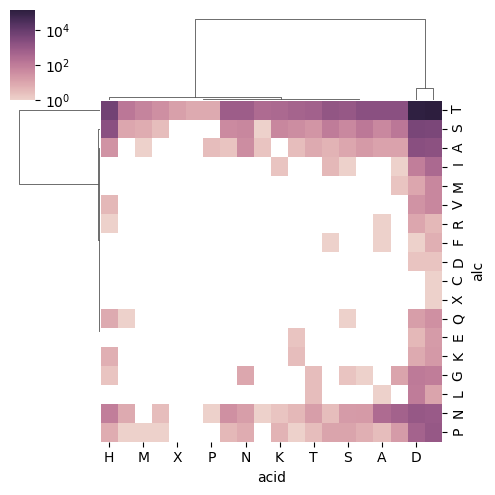

In [48]:
cmap = sns.cubehelix_palette(as_cmap=True)

cluster_map = sns.clustermap(
    heatmap_data,
    norm=LogNorm(),
    cmap=cmap,
    figsize=(5,5),
    dendrogram_ratio=(.2, .2)
    )